Found 1631 positive records and 21799 negative records.


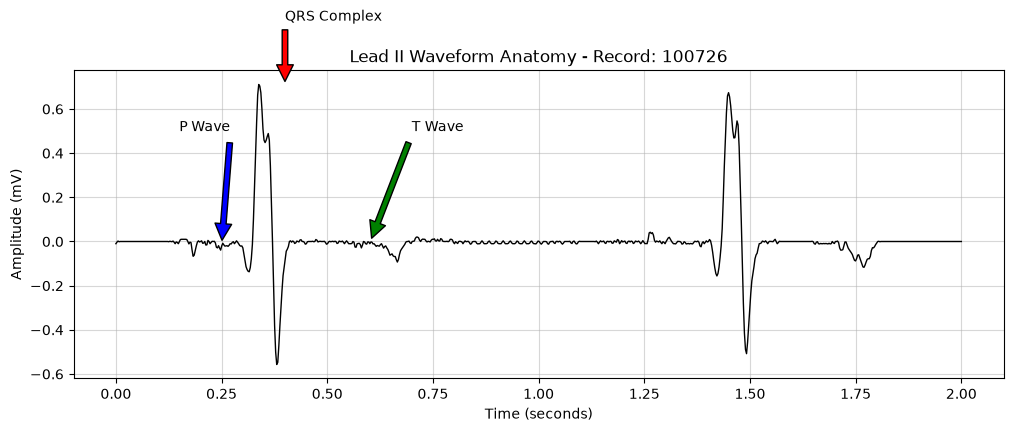

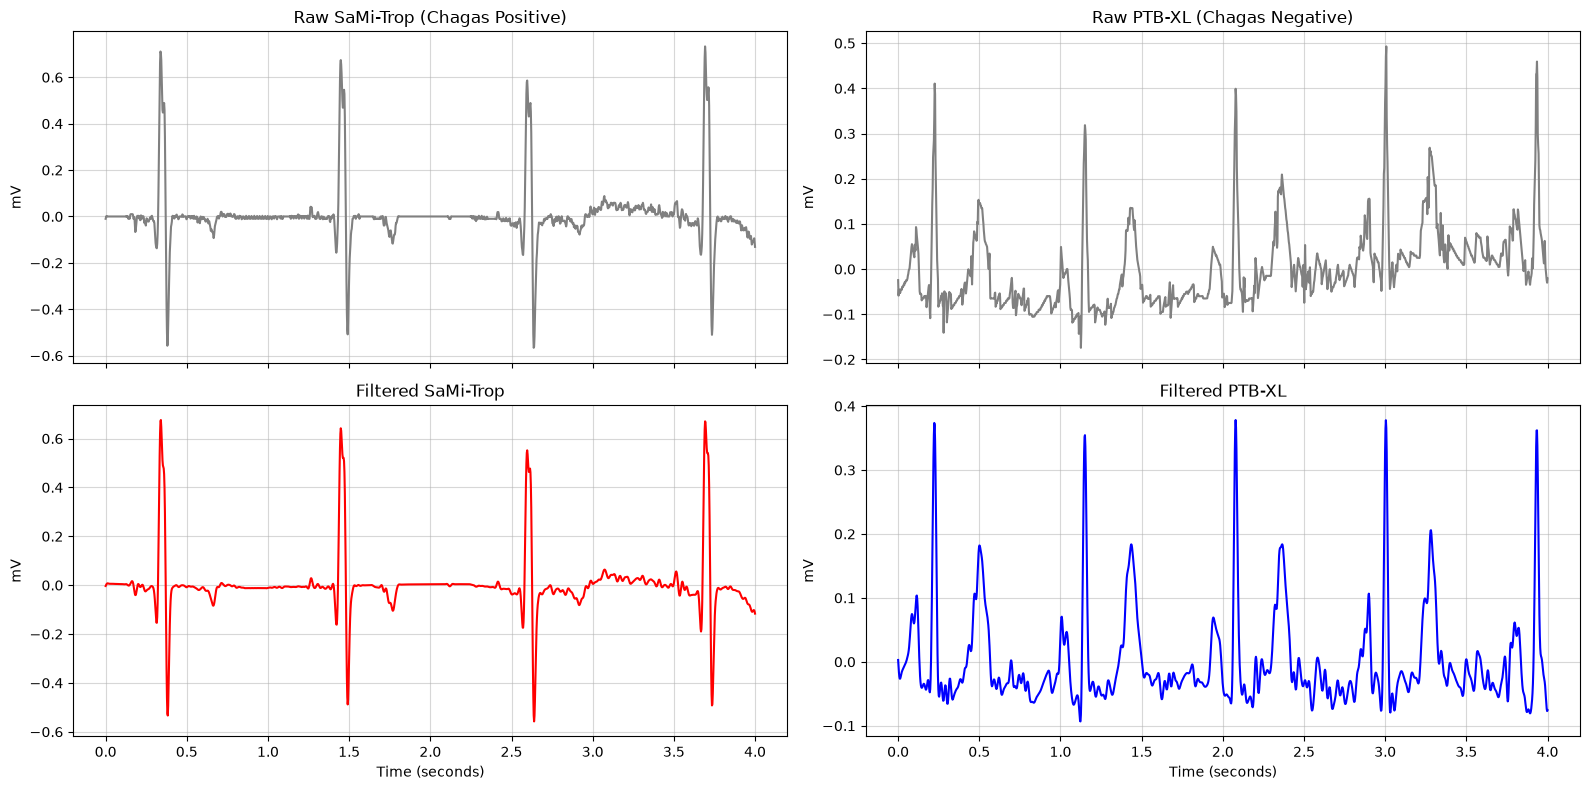

In [5]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, resample
import glob
import os

# --- 1. Setup & Load Records ---
sami_dir = 'samitrop_wfdb/'
ptb_dir = 'ptbxl_wfdb/'

# CHANGED: Added ** and recursive=True to dig into the subfolders!
sami_records = sorted([f.replace('.hea', '') for f in glob.glob(os.path.join(sami_dir, '**/*.hea'), recursive=True)])
ptb_records = sorted([f.replace('.hea', '') for f in glob.glob(os.path.join(ptb_dir, '**/*.hea'), recursive=True)])
print(f"Found {len(sami_records)} positive records and {len(ptb_records)} negative records.")

# --- 2. Waveform Anatomy (P, QRS, T) ---
rec_sami = wfdb.rdrecord(sami_records[0])
fs_sami = rec_sami.fs
lead_ii = rec_sami.p_signal[:, 1] 

time = np.linspace(0, 2, 2 * fs_sami)
signal_window = lead_ii[0:2*fs_sami]

plt.figure(figsize=(12, 4))
plt.plot(time, signal_window, color='black', linewidth=1)
plt.annotate('P Wave', xy=(0.25, signal_window[int(0.25*fs_sami)]), xytext=(0.15, 0.5), arrowprops=dict(facecolor='blue', shrink=0.05))
plt.annotate('QRS Complex', xy=(0.4, np.max(signal_window)), xytext=(0.4, 1.0), arrowprops=dict(facecolor='red', shrink=0.05))
plt.annotate('T Wave', xy=(0.6, signal_window[int(0.6*fs_sami)]), xytext=(0.7, 0.5), arrowprops=dict(facecolor='green', shrink=0.05))
plt.title(f'Lead II Waveform Anatomy - Record: {rec_sami.record_name}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.5)
plt.show()

# --- 3. Digital Filters & Side-by-Side Comparison ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs 
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, cutoff, fs, q=30.0):
    b, a = iirnotch(cutoff / (0.5 * fs), q)
    return filtfilt(b, a, data)

rec_ptb = wfdb.rdrecord(ptb_records[0])
fs_ptb = rec_ptb.fs
lead_ii_ptb = resample(rec_ptb.p_signal[:, 1], int(len(rec_ptb.p_signal[:, 1]) * (fs_sami / fs_ptb)))

clean_sami = notch_filter(bandpass_filter(lead_ii, 0.5, 40.0, fs_sami), 50.0, fs_sami)
clean_ptb = notch_filter(bandpass_filter(lead_ii_ptb, 0.5, 40.0, fs_sami), 50.0, fs_sami)

fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
time_window = np.linspace(0, 4, 4 * fs_sami) 

axs[0, 0].plot(time_window, lead_ii[:4*fs_sami], color='gray')
axs[0, 0].set_title('Raw SaMi-Trop (Chagas Positive)')
axs[1, 0].plot(time_window, clean_sami[:4*fs_sami], color='red')
axs[1, 0].set_title('Filtered SaMi-Trop')

axs[0, 1].plot(time_window, lead_ii_ptb[:4*fs_sami], color='gray')
axs[0, 1].set_title('Raw PTB-XL (Chagas Negative)')
axs[1, 1].plot(time_window, clean_ptb[:4*fs_sami], color='blue')
axs[1, 1].set_title('Filtered PTB-XL')

for ax in axs.flat:
    ax.grid(True, alpha=0.5)
    ax.set_ylabel('mV')
axs[1, 0].set_xlabel('Time (seconds)')
axs[1, 1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()